# Лабораторна робота: аналіз набору даних та візуалізація





In [10]:
import os
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Спроба автоматично знайти csv у поточній папці
csv_candidates = list(Path(".").glob("*.csv"))
default_csv = "Teen_Mental_Health_Dataset.csv"

if Path(default_csv).exists():
    FILE_PATH = default_csv
elif csv_candidates:
    FILE_PATH = str(csv_candidates[0])
else:
    FILE_PATH = default_csv

CONFIG = {
    "columns_to_keep": [
        "age",
        "gender",
        "daily_social_media_hours",
        "platform_usage",
        "sleep_hours",
        "stress_level",
        "anxiety_level",
        "addiction_level",
        "depression_label"
    ],
    "required_column": "stress_level",
    "bool_column": "depression_label",
    "numeric_columns": [
        "age",
        "daily_social_media_hours",
        "sleep_hours",
        "stress_level",
        "anxiety_level",
        "addiction_level"
    ],
    "main_numeric_filter_column": "daily_social_media_hours",
    "main_numeric_threshold": 5,
    "second_numeric_column": "stress_level",
    "top10_sort_column": "daily_social_media_hours",
    "exact_match_column": "gender",
    "exact_match_value": "female",
    "substring_column": "platform_usage",
    "substring_value": "Instagram",
    "equal_check_column": "age",
    "equal_check_value": 16,
    "range_column": "sleep_hours",
    "range_min": 6,
    "range_max": 8,
    "significant_column": "addiction_level",
    "significant_threshold": 7,
    "top5_sort_column": "stress_level",
    "top10_metric_sort_column": "daily_social_media_hours",
    "top10_metric_column": "anxiety_level",
    "group_column": "gender",
    "group_1": "male",
    "group_2": "female",
    "group_avg_column": "stress_level",
    "complex_filter_hours_threshold": 4,
    "complex_filter_stress_threshold": 7,
    "complex_filter_exclude_platform": "TikTok",
}

print(f"Використовується файл: {FILE_PATH}")

Використовується файл: Teen_Mental_Health_Dataset.csv


## Допоміжні функції

In [8]:
def print_title(title: str):
    print("\n" + "=" * 90)
    print(title)
    print("=" * 90)

def print_conclusion(text: str):
    print(f"\nВисновок: {text}")

def check_columns(df: pd.DataFrame, required_columns: list):
    missing = [col for col in required_columns if col not in df.columns]
    if missing:
        raise ValueError(
            f"У датасеті відсутні такі колонки: {missing}\n"
            f"Наявні колонки: {list(df.columns)}"
        )

def normalize_text_column(series: pd.Series) -> pd.Series:
    return series.astype(str).str.strip()

def save_current_plot(filename: str):
    plt.tight_layout()
    plt.savefig(filename, dpi=300, bbox_inches="tight")
    print(f"Графік збережено у файл: {filename}")

## Основний аналіз і побудова звіту


1.1 ВИБІР ТА ЗАВАНТАЖЕННЯ НАБОРУ ДАНИХ
Перші 5 рядків початкового набору даних:
   age  gender  daily_social_media_hours platform_usage  sleep_hours  \
0   14    male                       7.9      Instagram          7.4   
1   19  female                       1.9         TikTok          8.0   
2   17  female                       1.3      Instagram          7.6   
3   15    male                       7.4         TikTok          6.9   
4   15  female                       4.7           Both          4.9   

   screen_time_before_sleep  academic_performance  physical_activity  \
0                       2.9                  3.01                1.5   
1                       2.9                  3.22                0.8   
2                       0.5                  3.92                0.0   
3                       1.6                  3.48                0.8   
4                       3.0                  2.37                1.4   

  social_interaction_level  stress_level  anxiety_lev

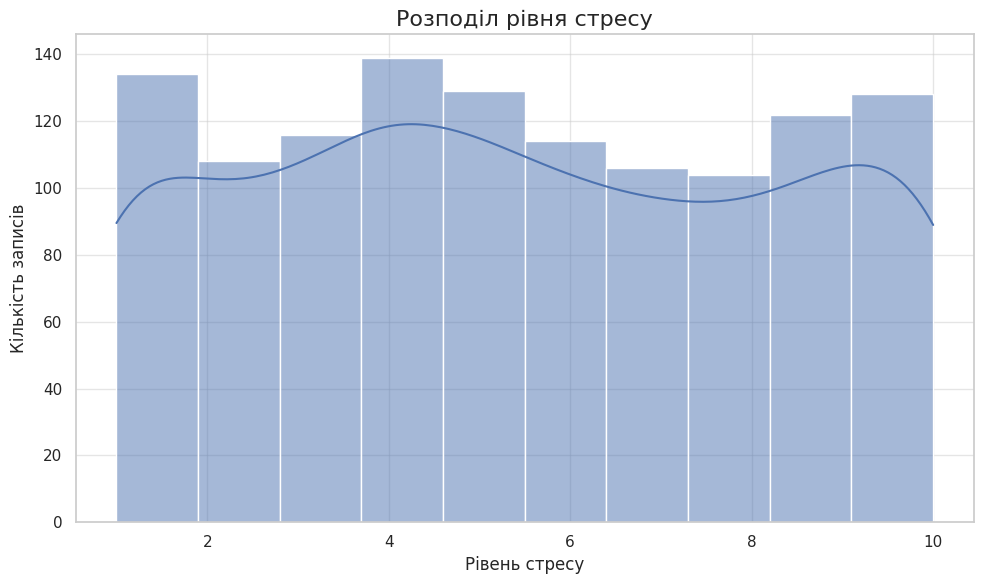

Графік збережено у файл: diagram_2_avg_stress_by_platform.png


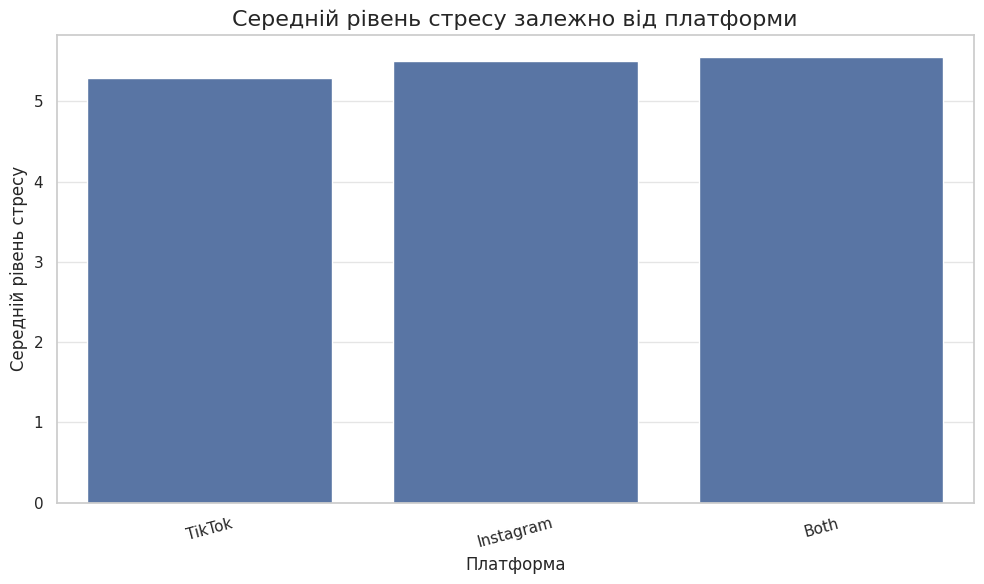

Графік збережено у файл: diagram_3_anxiety_boxplot.png


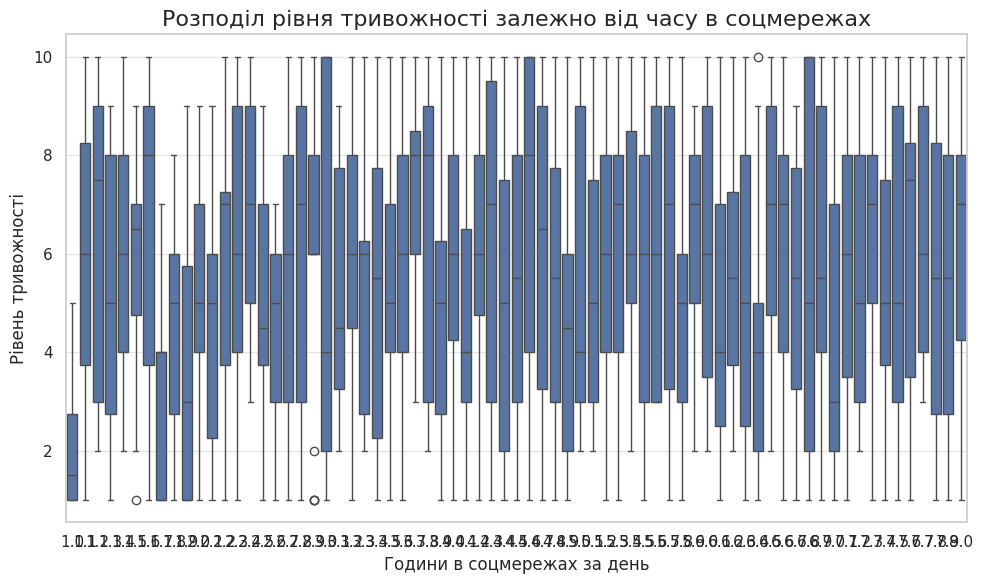

In [11]:
print_title("1.1 ВИБІР ТА ЗАВАНТАЖЕННЯ НАБОРУ ДАНИХ")
df = pd.read_csv(FILE_PATH)
df.columns = df.columns.str.strip()
print("Перші 5 рядків початкового набору даних:")
print(df.head())
print("\nНазви колонок у датасеті:")
print(df.columns.tolist())
check_columns(df, CONFIG["columns_to_keep"])
print_conclusion(
    "Набір даних успішно завантажено. Він містить необхідні текстові та числові ознаки."
)
print_title("1.2 ОЧИЩЕННЯ НАБОРУ ДАНИХ")
# Залишаємо лише потрібні колонки
df = df[CONFIG["columns_to_keep"]].copy()
# Створюємо ідентифікатор запису
df = df.reset_index(drop=True)
df.insert(0, "record_id", df.index + 1)
print("Після очищення залишили такі колонки:")
print(df.columns.tolist())
print("\nПерші 5 рядків після очищення:")
print(df.head())
print_conclusion(
    "Видалено зайві стовпчики. Для подальшого аналізу залишено 9 основних ознак."
)
print_title("1.3 ОБРОБКА ПРОПУЩЕНИХ ЗНАЧЕНЬ")
# Безпечне приведення числових колонок
for col in CONFIG["numeric_columns"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")
before_dropna = len(df)
df = df.dropna(subset=[CONFIG["required_column"]])
after_dropna = len(df)
print(f"Кількість рядків до видалення NaN у стовпчику '{CONFIG['required_column']}': {before_dropna}")
print(f"Кількість рядків після видалення NaN: {after_dropna}")
print(f"Видалено рядків: {before_dropna - after_dropna}")
if df.empty:
    raise ValueError("Після очищення DataFrame порожній. Перевірте вхідний файл.")
print_conclusion(
    f"Усі записи з порожнім значенням у ключовому стовпчику "
    f"'{CONFIG['required_column']}' були видалені."
)
print_title("1.4 ФОРМАТУВАННЯ ДАНИХ")
# Нормалізація текстових колонок
text_columns = ["gender", "platform_usage"]
for col in text_columns:
    df[col] = normalize_text_column(df[col])
df["gender"] = df["gender"].str.lower()
df["platform_usage"] = df["platform_usage"].str.strip()
# Перетворення depression_label до bool
df[CONFIG["bool_column"]] = (
    df[CONFIG["bool_column"]]
    .astype(str)
    .str.strip()
    .str.lower()
    .map({
        "yes": True,
        "no": False,
        "true": True,
        "false": False,
        "1": True,
        "0": False
    })
    .fillna(False)
    .astype(bool)
)
print("Типи даних після форматування:")
print(df.dtypes)
print_conclusion(
    "Категоріальні текстові значення нормалізовано, а depression_label приведено до булевого типу."
)
print_title("2.1 ЗАГАЛЬНА КІЛЬКІСТЬ РЯДКІВ")
print(f"Загальна кількість записів після попередньої очистки: {len(df)}")
print_conclusion("Підраховано загальну кількість записів після очищення даних.")
print_title("2.2 РОБОТА З ЧИСЛОВИМИ ПОКАЗНИКАМИ")
filtered_numeric = df[
    df[CONFIG["main_numeric_filter_column"]] > CONFIG["main_numeric_threshold"]
].copy()
print(
    f"1) Відфільтровано записи, де "
    f"{CONFIG['main_numeric_filter_column']} > {CONFIG['main_numeric_threshold']}"
)
print(f"2) Кількість таких записів: {len(filtered_numeric)}")
avg_value = filtered_numeric[CONFIG["second_numeric_column"]].mean()
print(
    f"3) Середнє значення стовпчика '{CONFIG['second_numeric_column']}' "
    f"для цієї вибірки: {avg_value:.2f}"
)
top_10_ids = df.nlargest(10, CONFIG["top10_sort_column"])["record_id"]
print(
    f"4) Ідентифікатори 10 записів з найбільшим значенням "
    f"'{CONFIG['top10_sort_column']}':"
)
print(top_10_ids.to_list())
print("\nДодатково покажемо самі записи:")
print(
    df.nlargest(10, CONFIG["top10_sort_column"])[
        ["record_id", "daily_social_media_hours", "age", "gender", "platform_usage"]
    ]
)
print_conclusion(
    "Було виконано фільтрацію за числовим порогом, підрахунок, обчислення середнього та пошук топ-10 записів."
)
print_title("2.3 ДОСЛІДЖЕННЯ КАТЕГОРІЙ ТА ТЕКСТУ")
cond1 = df[CONFIG["exact_match_column"]] == CONFIG["exact_match_value"]
cond2 = df[CONFIG["substring_column"]].str.contains(
    CONFIG["substring_value"], case=False, na=False
)
substring_filtered = df[cond2].copy()
exact_match_count = cond1.sum()
both_conditions_count = (cond1 & cond2).sum()
only_first_count = (cond1 & ~cond2).sum()
only_first_share = only_first_count / exact_match_count if exact_match_count > 0 else 0
neither_count = (~cond1 & ~cond2).sum()
print(
    f"1) Кількість записів, де "
    f"{CONFIG['exact_match_column']} == '{CONFIG['exact_match_value']}': {exact_match_count}"
)
print(
    f"2) Кількість записів, де у стовпчику '{CONFIG['substring_column']}' "
    f"міститься підрядок '{CONFIG['substring_value']}': {len(substring_filtered)}"
)
print(f"3) Кількість записів, які одночасно задовольняють обидві умови: {both_conditions_count}")
print(f"4) Частка записів, які задовольняють умову 1, але не умову 2: {only_first_share:.4f}")
print(f"5) Кількість записів, які не задовольняють жодну з двох умов: {neither_count}")
print_conclusion(
    "Було досліджено категоріальні ознаки за точним та частковим збігом."
)
print_title("2.4 ДОСЛІДЖЕННЯ ЧИСЛОВИХ ДІАПАЗОНІВ ТА ЗРІЗІВ ДАНИХ")
count_equal = (df[CONFIG["equal_check_column"]] == CONFIG["equal_check_value"]).sum()
count_range = df[
    (df[CONFIG["range_column"]] >= CONFIG["range_min"]) &
    (df[CONFIG["range_column"]] <= CONFIG["range_max"])
].shape[0]
comparison_result = count_equal > count_range
print(
    f"1) Кількість записів, де "
    f"{CONFIG['equal_check_column']} == {CONFIG['equal_check_value']}: {count_equal}"
)
print(
    f"2) Кількість записів, де "
    f"{CONFIG['range_min']} <= {CONFIG['range_column']} <= {CONFIG['range_max']}: {count_range}"
)
print(f"3) Чи є кількість записів з першої умови більшою за другу? {comparison_result}")
print_conclusion(
    "Порівняно точковий зріз за конкретним значенням та зріз за числовим діапазоном."
)
print_title("2.5 КОМБІНОВАНІ ФІЛЬТРИ ТА ОЦІНКИ")
significant_df = df[df[CONFIG["significant_column"]] > CONFIG["significant_threshold"]].copy()
print(
    f"1) Кількість 'значущих' записів, де "
    f"{CONFIG['significant_column']} > {CONFIG['significant_threshold']}: {len(significant_df)}"
)
top_5_significant = significant_df.nlargest(5, CONFIG["top5_sort_column"])
print(f"\n2) Топ-5 записів з найвищим значенням '{CONFIG['top5_sort_column']}':")
print(
    top_5_significant[
        ["record_id", "age", "gender", "platform_usage", "addiction_level", "stress_level"]
    ]
)
top_10_other = df.nlargest(10, CONFIG["top10_metric_sort_column"])
top10_metric_mean = top_10_other[CONFIG["top10_metric_column"]].mean()
print(
    f"\n3) Середнє значення '{CONFIG['top10_metric_column']}' "
    f"для топ-10 записів, відсортованих за '{CONFIG['top10_metric_sort_column']}': "
    f"{top10_metric_mean:.2f}"
)
print_conclusion(
    "Виділено значущі записи, побудовано топ-5 та обчислено середнє значення для топ-10 іншої вибірки."
)
print_title("2.6 ПОРІВНЯННЯ ГРУП")
group_1_df = df[df[CONFIG["group_column"]] == CONFIG["group_1"]].copy()
group_2_df = df[df[CONFIG["group_column"]] == CONFIG["group_2"]].copy()
comparison_df = pd.DataFrame({
    "category_name": [CONFIG["group_1"], CONFIG["group_2"]],
    "total_records": [len(group_1_df), len(group_2_df)],
    "average_value": [
        group_1_df[CONFIG["group_avg_column"]].mean(),
        group_2_df[CONFIG["group_avg_column"]].mean()
    ]
})
print("Перший DataFrame:")
print(group_1_df.head())
print("\nДругий DataFrame:")
print(group_2_df.head())
print("\nНовий DataFrame для порівняння груп:")
print(comparison_df)
print_conclusion(
    "Створено два окремі DataFrame для різних категорій і новий DataFrame для їх порівняння."
)
print_title("2.7 КОМПЛЕКСНІ ЗАВДАННЯ")
complex_filter = df[
    (
        (df["daily_social_media_hours"] > CONFIG["complex_filter_hours_threshold"]) &
        (df["stress_level"] > CONFIG["complex_filter_stress_threshold"])
    )
    |
    (
        ~(df["platform_usage"].str.lower() == CONFIG["complex_filter_exclude_platform"].lower()) &
        (df["anxiety_level"] >= 8)
    )
].copy()
print("1) Результат складного фільтра з використанням AND, OR, NOT:")
print(f"Кількість записів: {len(complex_filter)}")
print(complex_filter.head())
print_conclusion(
    "Складний фільтр побудовано з одночасним використанням операторів AND, OR, NOT."
)
print_title("3. ПОБУДОВА ГРАФІКІВ")
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (10, 6)
# Графік 1: гістограма рівня стресу
plt.figure()
sns.histplot(data=df, x="stress_level", bins=10, kde=True)
plt.title("Розподіл рівня стресу", fontsize=16)
plt.xlabel("Рівень стресу", fontsize=12)
plt.ylabel("Кількість записів", fontsize=12)
save_current_plot("diagram_1_stress_hist.png")
plt.show()
plt.close()
# Графік 2: середній рівень стресу за платформою
avg_stress_by_platform = (
    df.groupby("platform_usage", as_index=False)["stress_level"]
    .mean()
    .sort_values("stress_level")
)
plt.figure()
sns.barplot(data=avg_stress_by_platform, x="platform_usage", y="stress_level")
plt.title("Середній рівень стресу залежно від платформи", fontsize=16)
plt.xlabel("Платформа", fontsize=12)
plt.ylabel("Середній рівень стресу", fontsize=12)
plt.xticks(rotation=15)
save_current_plot("diagram_2_avg_stress_by_platform.png")
plt.show()
plt.close()
# Графік 3: boxplot залежності тривожності від часу в соцмережах
plt.figure()
sns.boxplot(
    data=df,
    x="daily_social_media_hours",
    y="anxiety_level"
)
plt.title("Розподіл рівня тривожності залежно від часу в соцмережах", fontsize=16)
plt.xlabel("Години в соцмережах за день", fontsize=12)
plt.ylabel("Рівень тривожності", fontsize=12)
save_current_plot("diagram_3_anxiety_boxplot.png")
plt.show()
plt.close()